In [1]:
# Install if needed
!pip install pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(f"Pandas version  : {pd.__version__}")
print(f"NumPy version   : {np.__version__}")

Pandas version  : 2.3.3
NumPy version   : 2.3.5


In [2]:
df = pd.read_csv('Superstore_Formatted.csv')
print(f"Shape           : {df.shape}")
print(f"Total Rows      : {df.shape[0]:,}")
print(f"Total Columns   : {df.shape[1]}")
print(f"\nColumns:\n{df.columns.tolist()}")

Shape           : (9994, 24)
Total Rows      : 9,994
Total Columns   : 24

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Store', 'Store ID', 'Store Name']


In [3]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("\n First 5 Rows:")
display(df.head())

print("\n Data Types:")
print(df.dtypes)

print("\n Missing Values:")
print(df.isnull().sum())

print("\n Basic Statistics:")
display(df.describe())

DATASET OVERVIEW

 First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Store,Store ID,Store Name
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,Store_7,ST-SOU-01,Southern Superstore
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,Store_4,ST-SOU-01,Southern Superstore
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,Store_8,ST-WES-01,Western Superstore
3,4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,Store_5,ST-SOU-01,Southern Superstore
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Store_7,ST-SOU-01,Southern Superstore



 Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
Store             object
Store ID          object
Store Name        object
dtype: object

 Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity    

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:

np.random.seed(42)
n = len(df)
return_values = np.random.choice(['Yes', 'No', None], 
                                  size=n, 
                                  p=[0.30, 0.55, 0.15])

df['Returns'] = return_values
df['Returns'] = df['Returns'].replace({None: np.nan})

print("Before Imputation:")
print(df['Returns'].value_counts(dropna=False))
print(f"\nMissing values in Returns : {df['Returns'].isnull().sum()}")
print(f"Missing percentage        : {df['Returns'].isnull().mean()*100:.2f}%")

Before Imputation:
Returns
No     5498
Yes    3051
NaN    1445
Name: count, dtype: int64

Missing values in Returns : 1445
Missing percentage        : 14.46%


In [5]:

print("Before Conversion:")
print(f"Order Date dtype : {df['Order Date'].dtype}")
print(f"Ship Date dtype  : {df['Ship Date'].dtype}")
print(f"\nSample values:")
print(df[['Order Date', 'Ship Date']].head(3))

Before Conversion:
Order Date dtype : object
Ship Date dtype  : object

Sample values:
   Order Date   Ship Date
0  2016-08-11  2016-11-11
1  2016-08-11  2016-11-11
2  2016-12-06  2016-06-16


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%Y-%m-%d')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%Y-%m-%d')

print("After Conversion:")
print(f"Order Date dtype : {df['Order Date'].dtype}")
print(f"Ship Date dtype  : {df['Ship Date'].dtype}")


df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Order Day']     = df['Order Date'].dt.day_name()


df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print("\n Date columns converted successfully!")
print(f"\nSample extracted features:")
display(df[['Order Date', 'Order Year', 'Order Month', 
            'Order Quarter', 'Shipping Days']].head())

After Conversion:
Order Date dtype : datetime64[ns]
Ship Date dtype  : datetime64[ns]

 Date columns converted successfully!

Sample extracted features:


,Order Date,Order Year,Order Month,Order Quarter,Shipping Days
0,2016-08-11,2016,8,3,92
1,2016-08-11,2016,8,3,92
2,2016-12-06,2016,12,4,-173
3,2015-11-10,2015,11,4,-23
4,2015-11-10,2015,11,4,-23


In [7]:

import pandas as pd
import numpy as np
np.random.seed(42)
n = len(df)

return_values = np.random.choice(['Yes', 'No', None], 
                                  size=n, 
                                  p=[0.30, 0.55, 0.15])

df['Returns'] = return_values
df['Returns'] = df['Returns'].replace({None: np.nan})

print("Before Imputation:")
print(df['Returns'].value_counts(dropna=False))
print(f"\nMissing values  : {df['Returns'].isnull().sum()}")
print(f"Missing %       : {df['Returns'].isnull().mean()*100:.2f}%")
mode_value = df['Returns'].mode()[0]
print(f"\nMode value      : {mode_value}")

df['Returns_Mode_Imputed'] = df['Returns'].fillna(mode_value)
print(f"Missing after   : {df['Returns_Mode_Imputed'].isnull().sum()}")

df['Returns_Binary'] = df['Returns_Mode_Imputed'].apply(
    lambda x: 1 if x == 'Yes' else 0
)

df['Returns_Clean'] = df['Returns_Mode_Imputed']

print(f"\nBinary Distribution:")
print(df['Returns_Binary'].value_counts())
print(f"\nReturn Rate     : {df['Returns_Binary'].mean()*100:.2f}%")

Before Imputation:
Returns
No     5498
Yes    3051
NaN    1445
Name: count, dtype: int64

Missing values  : 1445
Missing %       : 14.46%

Mode value      : No
Missing after   : 0

Binary Distribution:
Returns_Binary
0    6943
1    3051
Name: count, dtype: int64

Return Rate     : 30.53%


In [8]:

print(f"   Mode value used     : {mode_value}")
print(f"   Missing after impute: {df['Returns_Clean'].isnull().sum()}")
print(f"   Binary flag created : Returns_Binary (0/1)")
print(f"   Return Rate         : {df['Returns_Binary'].mean()*100:.2f}%")
print(f"   Order Date dtype    : {df['Order Date'].dtype}")
print(f"   Ship Date dtype     : {df['Ship Date'].dtype}")
print(f"   Date range          : {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"   Avg Shipping Days   : {df['Shipping Days'].mean():.1f} days")


   Mode value used     : No
   Missing after impute: 0
   Binary flag created : Returns_Binary (0/1)
   Return Rate         : 30.53%
   Order Date dtype    : datetime64[ns]
   Ship Date dtype     : datetime64[ns]
   Date range          : 2014-01-02 to 2017-12-30
   Avg Shipping Days   : 9.3 days


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Superstore_EDA_Clean.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (9994, 33)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Store', 'Store ID', 'Store Name', 'Returns', 'Order Year', 'Order Month', 'Order Quarter', 'Order Day', 'Shipping Days', 'Returns_Mode_Imputed', 'Returns_Binary', 'Returns_Clean']


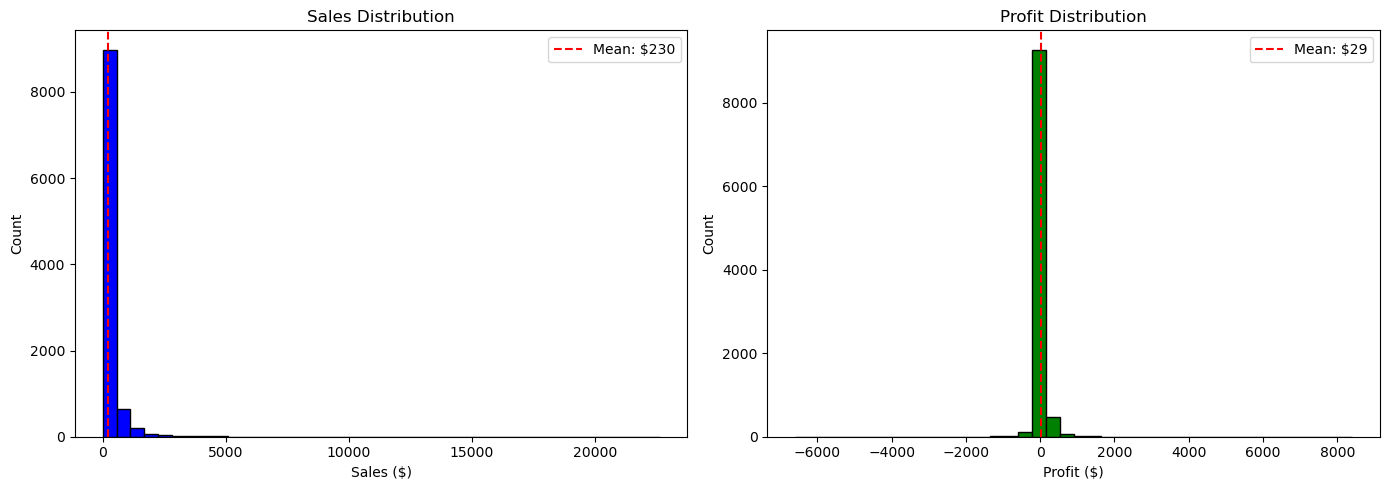

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Sales'], bins=40, color='blue', edgecolor='black')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Sales Distribution')
axes[0].axvline(df['Sales'].mean(), color='red', linestyle='--', 
                label=f'Mean: ${df["Sales"].mean():.0f}')
axes[0].legend()

axes[1].hist(df['Profit'], bins=40, color='green', edgecolor='black')
axes[1].set_xlabel('Profit ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Profit Distribution')
axes[1].axvline(df['Profit'].mean(), color='red', linestyle='--', 
                label=f'Mean: ${df["Profit"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('./01_Distribution.png', dpi=300)
plt.show()

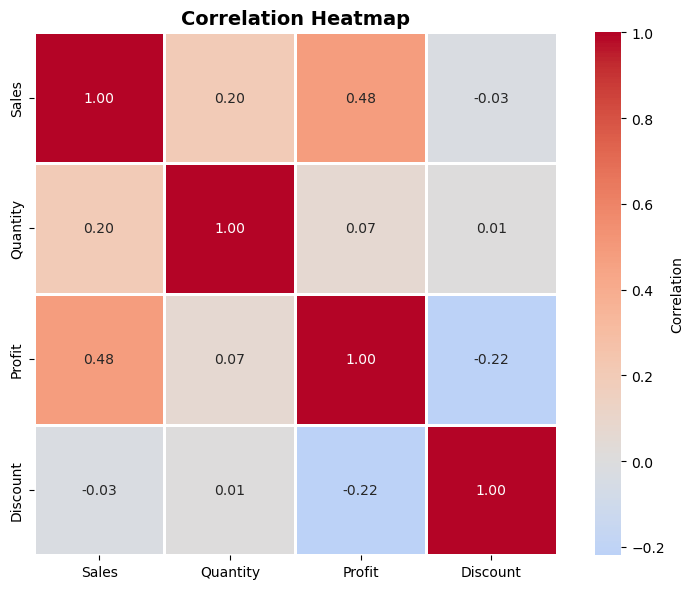

Correlations:
             Sales  Quantity    Profit  Discount
Sales     1.000000  0.200795  0.479064 -0.028190
Quantity  0.200795  1.000000  0.066253  0.008623
Profit    0.479064  0.066253  1.000000 -0.219487
Discount -0.028190  0.008623 -0.219487  1.000000


In [11]:
corr_cols = ['Sales', 'Quantity', 'Profit', 'Discount']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=2, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Downloads/02_Correlation.png', dpi=300)
plt.show()

print("Correlations:")
print(corr_matrix)

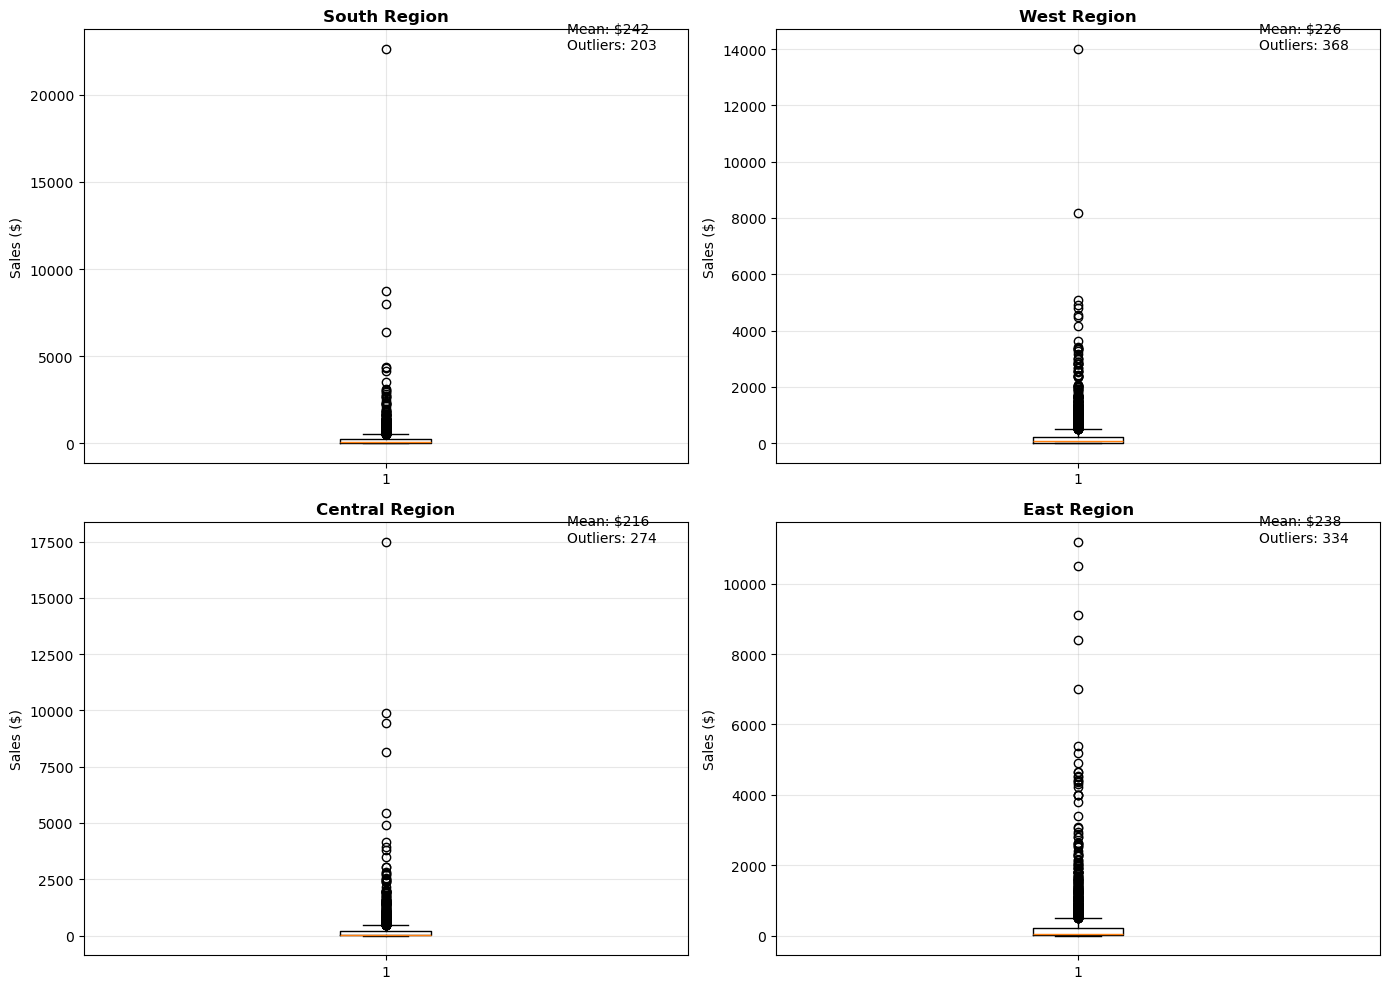

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

regions = df['Region'].unique()

for i, region in enumerate(regions):
    region_sales = df[df['Region'] == region]['Sales']
    
    axes[i].boxplot(region_sales, vert=True)
    axes[i].set_title(f'{region} Region', fontweight='bold')
    axes[i].set_ylabel('Sales ($)')
    axes[i].grid(True, alpha=0.3)
    
    Q1 = region_sales.quantile(0.25)
    Q3 = region_sales.quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = len(region_sales[(region_sales < Q1 - 1.5*IQR) | 
                                     (region_sales > Q3 + 1.5*IQR)])
    
    info = f"Mean: ${region_sales.mean():.0f}\nOutliers: {outlier_count}"
    axes[i].text(1.3, region_sales.max(), info, fontsize=10)

plt.tight_layout()
plt.savefig('./03_Regional_Outliers.png', dpi=300)
plt.show()

In [13]:
print("OUTLIER ANALYSIS BY REGION")
print("=" * 60)

for region in df['Region'].unique():
    region_sales = df[df['Region'] == region]['Sales']
    
    Q1 = region_sales.quantile(0.25)
    Q3 = region_sales.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = region_sales[(region_sales < lower) | (region_sales > upper)]
    
    print(f"\n{region}:")
    print(f"  Total records: {len(region_sales)}")
    print(f"  Average sales: ${region_sales.mean():.2f}")
    print(f"  Outliers: {len(outliers)} ({len(outliers)/len(region_sales)*100:.1f}%)")
    print(f"  Upper threshold: ${upper:.2f}")

OUTLIER ANALYSIS BY REGION

South:
  Total records: 1620
  Average sales: $241.80
  Outliers: 203 (12.5%)
  Upper threshold: $496.02

West:
  Total records: 3203
  Average sales: $226.49
  Outliers: 368 (11.5%)
  Upper threshold: $510.36

Central:
  Total records: 2323
  Average sales: $215.77
  Outliers: 274 (11.8%)
  Upper threshold: $478.10

East:
  Total records: 2848
  Average sales: $238.34
  Outliers: 334 (11.7%)
  Upper threshold: $497.76


In [14]:
negative = df[df['Profit'] < 0]

print(f"\nNegative Profit Records:")
print(f"Total: {len(negative)} records ({len(negative)/len(df)*100:.1f}%)")
print(f"\nTop 10 biggest losses:")
print(negative.nsmallest(10, 'Profit')[['Category', 'Sub-Category', 
                                        'Sales', 'Profit', 'Discount']])


Negative Profit Records:
Total: 1871 records (18.7%)

Top 10 biggest losses:
             Category Sub-Category      Sales     Profit  Discount
7772       Technology     Machines   4499.985 -6599.9780       0.7
683        Technology     Machines   7999.980 -3839.9904       0.5
9774  Office Supplies      Binders   2177.584 -3701.8928       0.8
3011       Technology     Machines   2549.985 -3399.9800       0.7
4991  Office Supplies      Binders   1889.990 -2929.4845       0.8
3151       Technology     Machines   1799.994 -2639.9912       0.7
5310  Office Supplies      Binders   1525.188 -2287.7820       0.8
9639        Furniture       Tables   4297.644 -1862.3124       0.4
1199  Office Supplies      Binders   1088.792 -1850.9464       0.8
2697       Technology     Machines  22638.480 -1811.0784       0.5


In [15]:
df.to_csv('Superstore_Final_Clean.csv', index=False)
print("  01_Distribution.png")
print("  02_Correlation.png")
print("  03_Regional_Outliers.png")
print("  Superstore_Final_Clean.csv")

  01_Distribution.png
  02_Correlation.png
  03_Regional_Outliers.png
  Superstore_Final_Clean.csv


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Superstore_Final_Clean.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

daily_sales = df.groupby('Order Date')['Sales'].sum().sort_index()

print(f"Data shape: {daily_sales.shape}")
print(f"Date range: {daily_sales.index.min()} to {daily_sales.index.max()}")

Data shape: (1237,)
Date range: 2014-01-02 00:00:00 to 2017-12-30 00:00:00


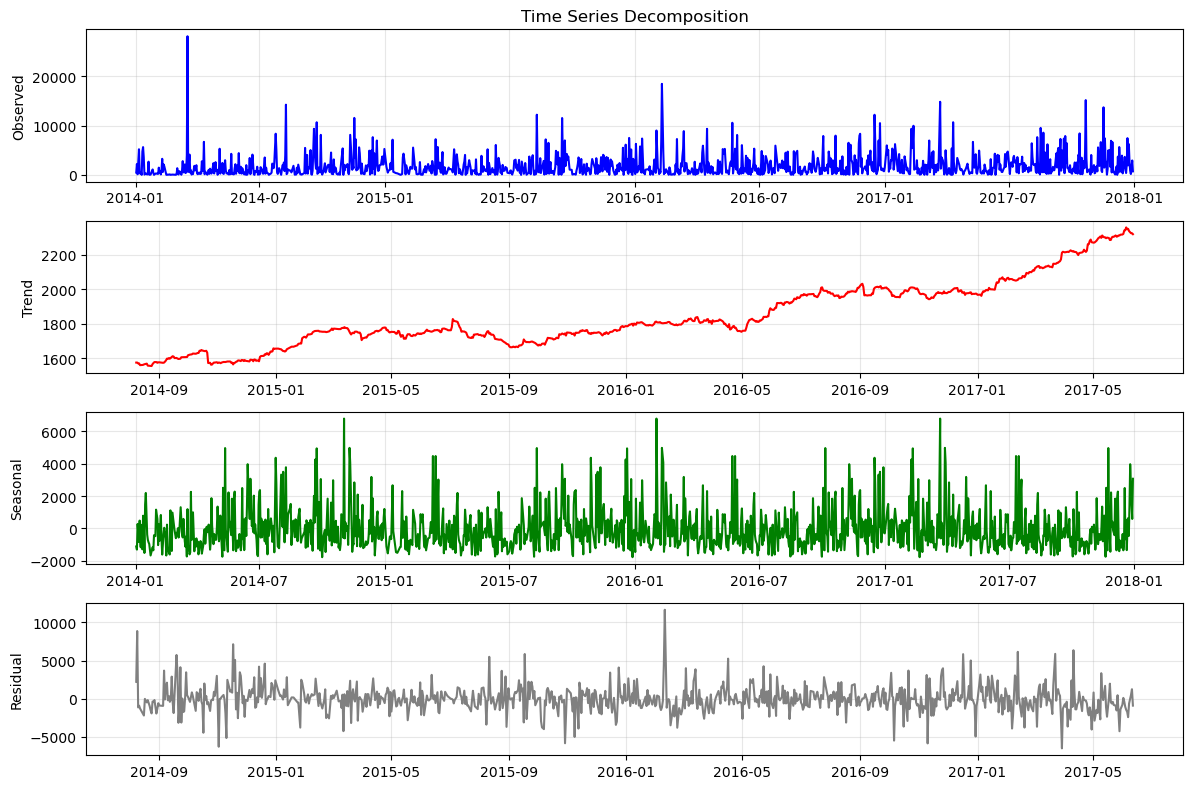

In [17]:
decomposition = seasonal_decompose(daily_sales, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(12, 8))

axes[0].plot(decomposition.observed, color='blue')
axes[0].set_ylabel('Observed')
axes[0].set_title('Time Series Decomposition')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomposition.trend, color='red')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomposition.seasonal, color='green')
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomposition.resid, color='gray')
axes[3].set_ylabel('Residual')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
trend = decomposition.trend.dropna()

print("Trend Analysis")
print(f"Mean: ${trend.mean():.2f}")
print(f"Min: ${trend.min():.2f}")
print(f"Max: ${trend.max():.2f}")
print(f"Change: ${trend.iloc[-1] - trend.iloc[0]:.2f}")

Trend Analysis
Mean: $1847.07
Min: $1553.80
Max: $2359.27
Change: $746.25


In [19]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

print("Top 10 Peak Months:")
top_10 = monthly_sales.nlargest(10)
for i, (date, sales) in enumerate(top_10.items(), 1):
    print(f"{i}. {date.strftime('%B %Y')}: ${sales:,.2f}")

Top 10 Peak Months:
1. November 2017: $89,306.24
2. August 2017: $75,675.30
3. March 2017: $74,774.08
4. September 2017: $74,164.61
5. December 2016: $72,954.16
6. November 2016: $66,837.59
7. September 2015: $66,729.33
8. September 2014: $66,110.22
9. October 2017: $65,501.16
10. December 2014: $65,426.31


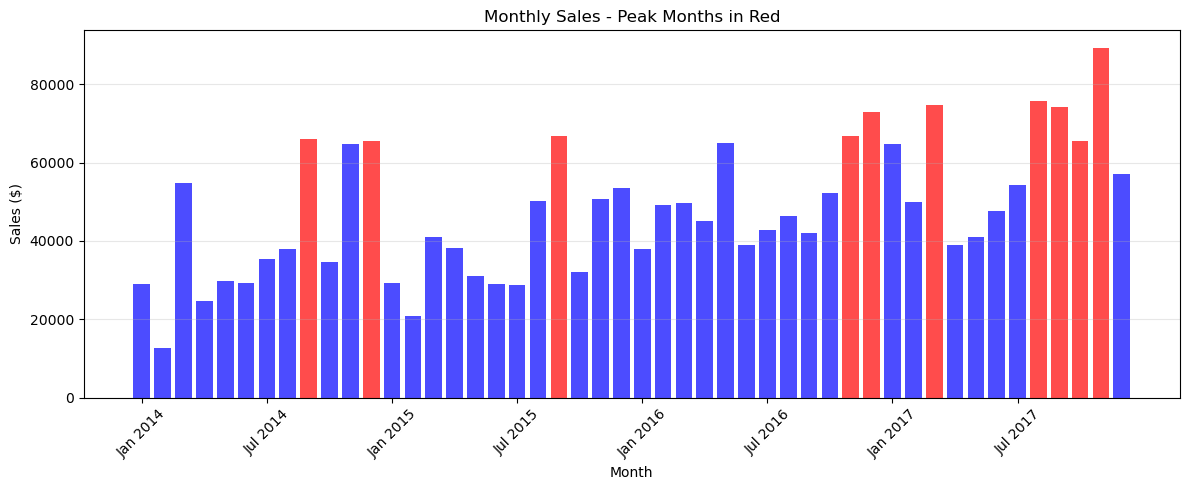

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))

top_months = monthly_sales.nlargest(10)
colors = ['red' if sales in top_months.values else 'blue' for sales in monthly_sales.values]

ax.bar(range(len(monthly_sales)), monthly_sales.values, color=colors, alpha=0.7)
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($)')
ax.set_title('Monthly Sales - Peak Months in Red')
ax.grid(True, alpha=0.3, axis='y')

plt.xticks(range(0, len(monthly_sales), 6), 
           [monthly_sales.index[i].strftime('%b %Y') for i in range(0, len(monthly_sales), 6)],
           rotation=45)

plt.tight_layout()
plt.savefig('./peak_months.png', dpi=300)
plt.show()

In [21]:
print("Peak Months by Region")
print("=" * 50)

for region in df['Region'].unique():
    region_data = df[df['Region'] == region]
    region_monthly = region_data.groupby(region_data['Order Date'].dt.to_period('M'))['Sales'].sum()
    
    top_3 = region_monthly.nlargest(3)
    
    print(f"\n{region}:")
    for i, (month, sales) in enumerate(top_3.items(), 1):
        print(f"  {i}. {month}: ${sales:,.2f}")

Peak Months by Region

South:
  1. 2014-03: $33,368.82
  2. 2016-05: $18,248.89
  3. 2017-04: $15,147.33

West:
  1. 2017-03: $40,542.32
  2. 2017-08: $33,585.56
  3. 2016-10: $25,595.13

Central:
  1. 2017-01: $24,940.96
  2. 2016-02: $24,273.92
  3. 2016-12: $20,317.57

East:
  1. 2017-11: $38,044.54
  2. 2017-09: $32,756.09
  3. 2015-09: $31,013.36


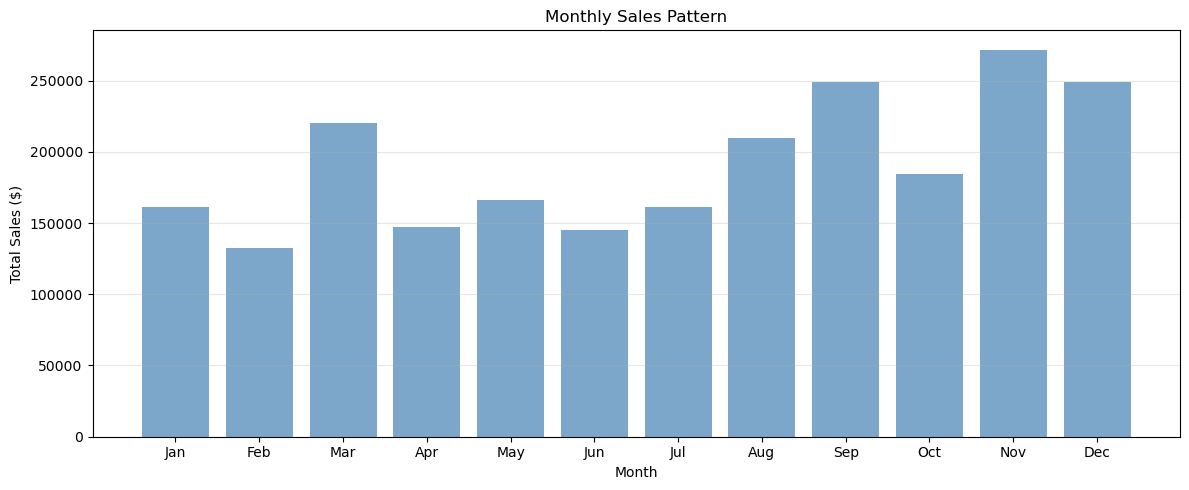

Monthly Average Sales:
Jan: $269.82
Feb: $242.19
Mar: $268.70
Apr: $210.95
May: $201.48
Jun: $204.93
Jul: $217.87
Aug: $257.31
Sep: $218.80
Oct: $228.16
Nov: $223.98
Dec: $229.28


In [22]:
df['Month'] = df['Order Date'].dt.month

monthly_avg = df.groupby('Month')['Sales'].agg(['mean', 'sum'])

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(monthly_avg.index, monthly_avg['sum'], color='steelblue', alpha=0.7)
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.set_title('Monthly Sales Pattern')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('./monthly_pattern.png', dpi=300)
plt.show()

print("Monthly Average Sales:")
for month, avg in zip(month_names, monthly_avg['mean']):
    print(f"{month}: ${avg:,.2f}")

In [23]:
print("Time Series Analysis Summary")
print("=" * 50)
print(f"Period: {daily_sales.index.min().date()} to {daily_sales.index.max().date()}")
print(f"Average Daily Sales: ${daily_sales.mean():.2f}")
print(f"Total Days: {len(daily_sales)}")

trend = decomposition.trend.dropna()
print(f"Trend Direction: {'Increasing' if trend.iloc[-1] > trend.iloc[0] else 'Decreasing'}")

peak_month = monthly_avg['sum'].idxmax()
print(f"Peak Month: {month_names[peak_month - 1]}")

low_month = monthly_avg['sum'].idxmin()
print(f"Low Month: {month_names[low_month - 1]}")

Time Series Analysis Summary
Period: 2014-01-02 to 2017-12-30
Average Daily Sales: $1857.07
Total Days: 1237
Trend Direction: Increasing
Peak Month: Nov
Low Month: Feb


In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('Superstore_Final_Clean.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [25]:
last_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (last_date - x.max()).days,
    'Order ID': 'count',
    'Sales': 'sum'
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

print(rfm.head())
print(f"\nRecency: avg {rfm['Recency'].mean():.0f} days")
print(f"Frequency: avg {rfm['Frequency'].mean():.0f} purchases")
print(f"Monetary: avg ${rfm['Monetary'].mean():.2f}")

  Customer ID  Recency  Frequency  Monetary
0    AA-10315      185         11  5563.560
1    AA-10375       49         15  1056.390
2    AA-10480      260         12  1790.512
3    AA-10645      234         18  5086.935
4    AB-10015      446          6   886.156

Recency: avg 164 days
Frequency: avg 13 purchases
Monetary: avg $2896.85


In [26]:
scaler = StandardScaler()
rfm_scaled = rfm.copy()
rfm_scaled[['Recency', 'Frequency', 'Monetary']] = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

In [27]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled[['Recency', 'Frequency', 'Monetary']])

print("Cluster sizes:")
print(rfm['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    253
1    109
2    431
Name: count, dtype: int64


In [28]:
def get_label(row):
    r = row['Recency']
    f = row['Frequency']
    m = row['Monetary']
    
    r_median = rfm['Recency'].median()
    f_median = rfm['Frequency'].median()
    m_median = rfm['Monetary'].median()
    
    if f > f_median and m > m_median:
        return 'Loyalists'
    elif m < rfm['Monetary'].quantile(0.25):
        return 'Bargain Hunters'
    elif r > rfm['Recency'].quantile(0.75):
        return 'At Risk'
    else:
        return 'Bargain Hunters'

rfm['Label'] = rfm.apply(get_label, axis=1)

print("Customer segments:")
print(rfm['Label'].value_counts())

Customer segments:
Label
Bargain Hunters    420
Loyalists          282
At Risk             91
Name: count, dtype: int64


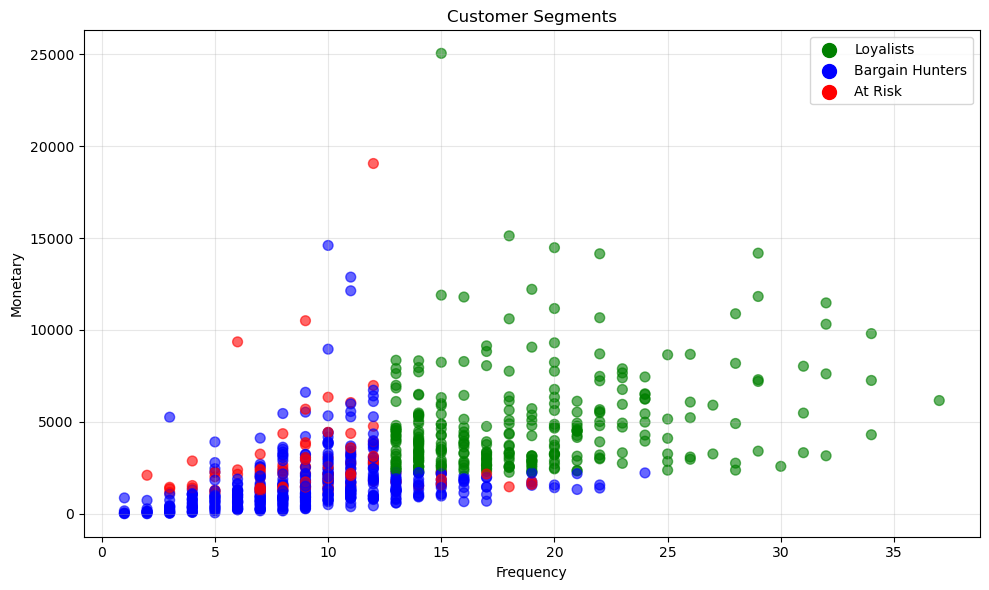

In [29]:
colors = {'Loyalists': 'green', 'Bargain Hunters': 'blue', 'At Risk': 'red'}
color_list = [colors[label] for label in rfm['Label']]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(rfm['Frequency'], rfm['Monetary'], c=color_list, alpha=0.6, s=50)
ax.set_xlabel('Frequency')
ax.set_ylabel('Monetary')
ax.set_title('Customer Segments')
ax.grid(True, alpha=0.3)

for label, color in colors.items():
    ax.scatter([], [], c=color, label=label, s=100)
ax.legend()

plt.tight_layout()

plt.show()

In [30]:
print("Segment Analysis")
print("=" * 50)

for label in rfm['Label'].unique():
    segment = rfm[rfm['Label'] == label]
    count = len(segment)
    pct = count / len(rfm) * 100
    revenue = segment['Monetary'].sum()
    
    print(f"\n{label}")
    print(f"  Count: {count} ({pct:.1f}%)")
    print(f"  Revenue: ${revenue:,.2f}")
    print(f"  Avg Recency: {segment['Recency'].mean():.0f} days")
    print(f"  Avg Frequency: {segment['Frequency'].mean():.1f} purchases")
    print(f"  Avg Spend: ${segment['Monetary'].mean():.2f}")

Segment Analysis

Bargain Hunters
  Count: 420 (53.0%)
  Revenue: $681,185.88
  Avg Recency: 146 days
  Avg Frequency: 9.2 purchases
  Avg Spend: $1621.87

At Risk
  Count: 91 (11.5%)
  Revenue: $246,715.95
  Avg Recency: 422 days
  Avg Frequency: 9.5 purchases
  Avg Spend: $2711.16

Loyalists
  Count: 282 (35.6%)
  Revenue: $1,369,299.02
  Avg Recency: 109 days
  Avg Frequency: 18.7 purchases
  Avg Spend: $4855.67


In [31]:
output = rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Label']]
output.to_csv('./customer_segments.csv', index=False)

print("Saved to customer_segments.csv")
print(output.head(10))

Saved to customer_segments.csv
  Customer ID  Recency  Frequency   Monetary            Label
0    AA-10315      185         11   5563.560  Bargain Hunters
1    AA-10375       49         15   1056.390  Bargain Hunters
2    AA-10480      260         12   1790.512          At Risk
3    AA-10645      234         18   5086.935        Loyalists
4    AB-10015      446          6    886.156  Bargain Hunters
5    AB-10060      106         18   7755.620        Loyalists
6    AB-10105       42         20  14473.571        Loyalists
7    AB-10150       42         12    966.710  Bargain Hunters
8    AB-10165      107         14   1113.838  Bargain Hunters
9    AB-10255      167         14    914.532  Bargain Hunters


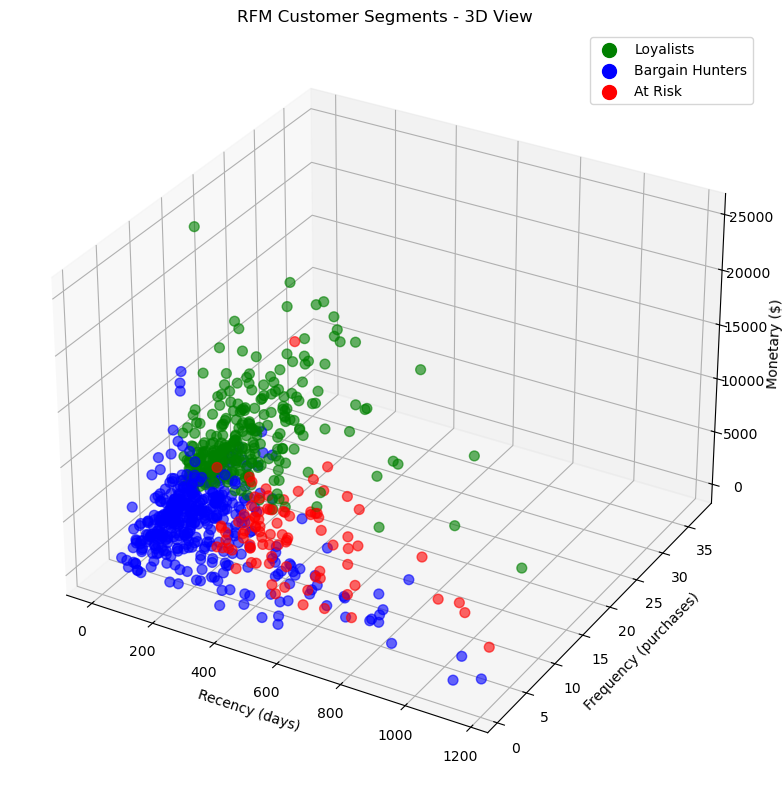

In [32]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

colors = {'Loyalists': 'green', 'Bargain Hunters': 'blue', 'At Risk': 'red'}
color_list = [colors[label] for label in rfm['Label']]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], 
           c=color_list, alpha=0.6, s=50)

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (purchases)')
ax.set_zlabel('Monetary ($)')
ax.set_title('RFM Customer Segments - 3D View')

for label, color in colors.items():
    ax.scatter([], [], [], c=color, label=label, s=100)
ax.legend()

plt.tight_layout()
plt.savefig('/Downloads/rfm_3d_plot.png', dpi=300)
plt.show()

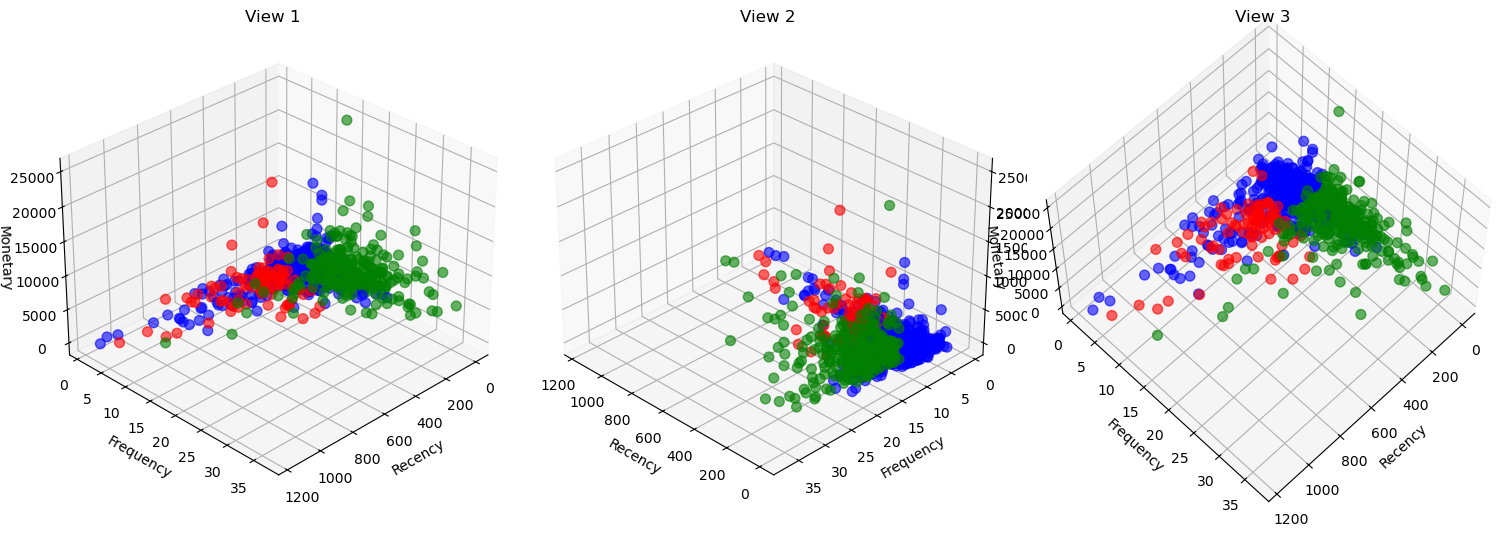

In [33]:
fig = plt.figure(figsize=(15, 5))

angles = [(30, 45), (30, 135), (60, 45)]

for i, (elev, azim) in enumerate(angles, 1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    
    ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], 
               c=color_list, alpha=0.6, s=50)
    
    ax.set_xlabel('Recency')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('Monetary')
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f'View {i}')

plt.tight_layout()
plt.savefig('./rfm_3d_multiple_views.png', dpi=300)
plt.show()

In [34]:
customer_segments = rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Label']].copy()

customer_segments.to_csv('./customer_segments.csv', index=False)

print("Customer segments exported successfully")
print(f"Total records: {len(customer_segments)}")
print(customer_segments.head(10))

Customer segments exported successfully
Total records: 793
  Customer ID  Recency  Frequency   Monetary            Label
0    AA-10315      185         11   5563.560  Bargain Hunters
1    AA-10375       49         15   1056.390  Bargain Hunters
2    AA-10480      260         12   1790.512          At Risk
3    AA-10645      234         18   5086.935        Loyalists
4    AB-10015      446          6    886.156  Bargain Hunters
5    AB-10060      106         18   7755.620        Loyalists
6    AB-10105       42         20  14473.571        Loyalists
7    AB-10150       42         12    966.710  Bargain Hunters
8    AB-10165      107         14   1113.838  Bargain Hunters
9    AB-10255      167         14    914.532  Bargain Hunters


In [35]:
df_with_segment = df.merge(rfm[['Customer ID', 'Label']], on='Customer ID', how='left')

df_with_segment.to_csv('./superstore_with_segments.csv', index=False)

print("Full dataset with segments exported")
print(f"Records: {len(df_with_segment)}")
print(df_with_segment[['Customer Name', 'Sales', 'Label']].head(10))

Full dataset with segments exported
Records: 9994
     Customer Name     Sales            Label
0      Claire Gute  261.9600          At Risk
1      Claire Gute  731.9400          At Risk
2  Darrin Van Huff   14.6200  Bargain Hunters
3   Sean O'Donnell  957.5775        Loyalists
4   Sean O'Donnell   22.3680        Loyalists
5  Brosina Hoffman   48.8600        Loyalists
6  Brosina Hoffman    7.2800        Loyalists
7  Brosina Hoffman  907.1520        Loyalists
8  Brosina Hoffman   18.5040        Loyalists
9  Brosina Hoffman  114.9000        Loyalists


In [36]:
print("SEGMENT STATISTICS")
print("=" * 60)

for label in ['Loyalists', 'Bargain Hunters', 'At Risk']:
    segment = rfm[rfm['Label'] == label]
    
    print(f"\n{label.upper()}")
    print(f"  Customers: {len(segment)}")
    print(f"  % of Total: {len(segment)/len(rfm)*100:.1f}%")
    print(f"  Revenue: ${segment['Monetary'].sum():,.2f}")
    print(f"  Avg Spend: ${segment['Monetary'].mean():.2f}")
    print(f"  Avg Recency: {segment['Recency'].mean():.0f} days")
    print(f"  Avg Purchases: {segment['Frequency'].mean():.1f}")

SEGMENT STATISTICS

LOYALISTS
  Customers: 282
  % of Total: 35.6%
  Revenue: $1,369,299.02
  Avg Spend: $4855.67
  Avg Recency: 109 days
  Avg Purchases: 18.7

BARGAIN HUNTERS
  Customers: 420
  % of Total: 53.0%
  Revenue: $681,185.88
  Avg Spend: $1621.87
  Avg Recency: 146 days
  Avg Purchases: 9.2

AT RISK
  Customers: 91
  % of Total: 11.5%
  Revenue: $246,715.95
  Avg Spend: $2711.16
  Avg Recency: 422 days
  Avg Purchases: 9.5


In [37]:
report = f"""
CUSTOMER SEGMENTATION ANALYSIS REPORT
{'='*60}

DATASET OVERVIEW
Total Customers: {len(rfm)}
Analysis Date: {df['Order Date'].max().date()}

SEGMENT BREAKDOWN
Loyalists: {len(rfm[rfm['Label']=='Loyalists'])} customers ({len(rfm[rfm['Label']=='Loyalists'])/len(rfm)*100:.1f}%)
Bargain Hunters: {len(rfm[rfm['Label']=='Bargain Hunters'])} customers ({len(rfm[rfm['Label']=='Bargain Hunters'])/len(rfm)*100:.1f}%)
At Risk: {len(rfm[rfm['Label']=='At Risk'])} customers ({len(rfm[rfm['Label']=='At Risk'])/len(rfm)*100:.1f}%)

REVENUE DISTRIBUTION
Total Revenue: ${rfm['Monetary'].sum():,.2f}
Loyalists Revenue: ${rfm[rfm['Label']=='Loyalists']['Monetary'].sum():,.2f}
Bargain Hunters Revenue: ${rfm[rfm['Label']=='Bargain Hunters']['Monetary'].sum():,.2f}
At Risk Revenue: ${rfm[rfm['Label']=='At Risk']['Monetary'].sum():,.2f}

KEY INSIGHTS
1. Loyalists are {rfm[rfm['Label']=='Loyalists']['Frequency'].mean()/rfm['Frequency'].mean():.1f}x more frequent buyers
2. Loyalists spend {rfm[rfm['Label']=='Loyalists']['Monetary'].mean()/rfm['Monetary'].mean():.1f}x more
3. At Risk customers haven't purchased for {rfm[rfm['Label']=='At Risk']['Recency'].mean():.0f} days
4. Bargain Hunters account for {len(rfm[rfm['Label']=='Bargain Hunters'])/len(rfm)*100:.1f}% of customer base

RECOMMENDATIONS
- Focus retention efforts on Loyalists
- Create win-back campaigns for At Risk
- Develop discount strategies for Bargain Hunters
"""

print(report)

with open('./segmentation_report.txt', 'w') as f:
    f.write(report)

print("\nReport saved to segmentation_report.txt")


CUSTOMER SEGMENTATION ANALYSIS REPORT

DATASET OVERVIEW
Total Customers: 793
Analysis Date: 2017-12-30

SEGMENT BREAKDOWN
Loyalists: 282 customers (35.6%)
Bargain Hunters: 420 customers (53.0%)
At Risk: 91 customers (11.5%)

REVENUE DISTRIBUTION
Total Revenue: $2,297,200.86
Loyalists Revenue: $1,369,299.02
Bargain Hunters Revenue: $681,185.88
At Risk Revenue: $246,715.95

KEY INSIGHTS
1. Loyalists are 1.5x more frequent buyers
2. Loyalists spend 1.7x more
3. At Risk customers haven't purchased for 422 days
4. Bargain Hunters account for 53.0% of customer base

RECOMMENDATIONS
- Focus retention efforts on Loyalists
- Create win-back campaigns for At Risk
- Develop discount strategies for Bargain Hunters


Report saved to segmentation_report.txt


In [38]:
print("TOP 5 CUSTOMERS BY SEGMENT")
print("=" * 60)

for label in ['Loyalists', 'Bargain Hunters', 'At Risk']:
    print(f"\n{label}")
    top_5 = rfm[rfm['Label']==label].nlargest(5, 'Monetary')
    for i, row in top_5.iterrows():
        print(f"  {row['Customer ID']}: ${row['Monetary']:.2f} ({row['Frequency']:.0f} purchases)")

TOP 5 CUSTOMERS BY SEGMENT

Loyalists
  SM-20320: $25043.05 (15 purchases)
  RB-19360: $15117.34 (18 purchases)
  AB-10105: $14473.57 (20 purchases)
  KL-16645: $14175.23 (29 purchases)
  SC-20095: $14142.33 (22 purchases)

Bargain Hunters
  TA-21385: $14595.62 (10 purchases)
  HL-15040: $12873.30 (11 purchases)
  CC-12370: $12129.07 (11 purchases)
  CM-12385: $8954.02 (10 purchases)
  YS-21880: $6720.44 (12 purchases)

At Risk
  TC-20980: $19052.22 (12 purchases)
  BS-11365: $10501.65 (9 purchases)
  GT-14635: $9351.21 (6 purchases)
  RH-19510: $6979.18 (12 purchases)
  CM-12655: $6339.56 (10 purchases)


In [39]:
print("ANALYSIS COMPLETE")
print("=" * 60)
print("\nFiles Generated:")
print("  rfm_3d_plot.png")
print("  rfm_3d_multiple_views.png")
print("  customer_segments.csv")
print("  superstore_with_segments.csv")
print("  segmentation_report.txt")

print(f"\nCustomer Breakdown:")
print(f"  Total Customers: {len(rfm)}")
print(f"  Loyalists: {len(rfm[rfm['Label']=='Loyalists'])}")
print(f"  Bargain Hunters: {len(rfm[rfm['Label']=='Bargain Hunters'])}")
print(f"  At Risk: {len(rfm[rfm['Label']=='At Risk'])}")

print(f"\nRevenue Summary:")
print(f"  Total: ${rfm['Monetary'].sum():,.2f}")
print(f"  Avg per Customer: ${rfm['Monetary'].mean():,.2f}")

ANALYSIS COMPLETE

Files Generated:
  rfm_3d_plot.png
  rfm_3d_multiple_views.png
  customer_segments.csv
  superstore_with_segments.csv
  segmentation_report.txt

Customer Breakdown:
  Total Customers: 793
  Loyalists: 282
  Bargain Hunters: 420
  At Risk: 91

Revenue Summary:
  Total: $2,297,200.86
  Avg per Customer: $2,896.85
